# Практическое задание 3: решение уравнений в частных производных с помощью DeepOKAN

## Нейродиффуры 2025

### ФИО: Новикова Вера Дмитриевна

## Введение
В этом задании вы изучите работу сетей Колмогорова-Арнольда, получите практические навыки обучения нейронных операторов типа DeepONet, а также научитесь генерировать обучающие данные для решения дифференциальных уравнений с помощью нейронных операторов.

### Используемые библиотеки:
- [PyTorch](https://pytorch.org/) — инструмент для работы с нейронными сетями.
- [TensorBoard](https://www.tensorflow.org/tensorboard?hl=ru) — инструмент для логирования и визуализации.
- [NumPy](https://numpy.org/) — библиотека для научных вычислений.
- [tqdm](https://tqdm.github.io/) — инструмент для отображения прогресса.
- [Matplotlib](https://matplotlib.org/) — библиотека для визуализации.

In [1]:
import os
import random
from collections.abc import Callable

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, default_collate
from torch.utils.tensorboard import SummaryWriter

import numpy as np

from tqdm import tqdm
from matplotlib import pyplot as plt

2025-04-27 19:55:48.072009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745783748.358693      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745783748.438933      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Зафиксируйте сиды, чтобы сделать свои эксперименты [воспроизводимыми](https://pytorch.org/docs/stable/notes/randomness.html).

In [2]:
torch.manual_seed(1543)
np.random.seed(1543)
random.seed(1543)

## Часть 1. Генерация данных для обучения
В этой части задания вы научитесь генерировать данные для обучения нейронных операторов. Предлагается решать начально-краевую задачу для одномерного [уравнения Бюргерса](https://en.wikipedia.org/wiki/Burgers%27_equation)
$$
    \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial ^2u}{\partial x^2}
$$
в области $[0, 1] \times [0, 1]$ с нулевыми граничными условиями
$$
    u(0, t) = u(1, t) = 0, ~t \in [0, 1],
$$
и начальным условием
$$
    u(x, 0) = u_{0}, ~x \in [0, 1].
$$

В данном задании коэффициент вязкости $\nu$ фиксирован и задаёт семейство начально-краевых задач, различающихся только начальным условием $u_{0}$; оно и будет поступать на вход нейронному оператору. Помимо начального условия DeepONet, речь о котором пойдёт ниже, будет принимать на вход точку, в которой требуется вычислить значение функции $u$, являющейся решением задачи. В нашем случае эта точка задаётся парой $(x,~t) \in [0, 1] \times [0, 1]$.

Реализуйте класс [`BurgersDataset`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html), задающий выборку из четвёрок вида $(x,~t,~u_{0},~u(x, t))$ на равномерной сетке $(X_{N},~T_{M})$, где $X_{N} = \{x_{i}\}_{i = 1}^{N}$, $T_{M} = \{t_{i}\}_{i = 1}^{M}$. Для этого:
1. Сгенерируйте случайные функции, определяющие начальные условия $u_{0}$.
2. Вычислите значения каждой из функций $u_{0}$ на сетке $X_{N}$.
3. Для каждого начального условия получите решение $u(x, t)$ уравнения на сетке $(X_{N},~T_{M})$, пользуясь каким-нибудь численным методом.
4. Включите в выборку лишь случайное подмножество полученных четвёрок. Это **важно** для избежания переобучения.

### Генерация начальных условий
Для создания обучающей выборки вам потребуется множество функций, задающих начальные условия. Существуют различные способы генерации функций; в данном задании для этого предлагается использовать [гауссовский случайный процесс](https://d2l.ai/chapter_gaussian-processes/gp-priors.html). Поскольку наш курс не посвящён случайным процессам, соответствующий метод уже реализован за вас (см. метод `_generate_fn`).

### Численное решение начально-краевой задачи
Чтобы получить референсные значения решения начально-краевой задачи, можно использовать [метод конечных разностей](https://en.wikipedia.org/wiki/Finite_difference_method). В этом методе производные, входящие в уравнение, аппроксимируются на заданной сетке конечными разностями. Для рассматриваемого уравнения Бюргерса можно выписать явную разностную схему первого порядка аппроксимации
$$
    \frac{u^{n+1}_{i} - u^{n}_{i}}{\Delta t} + u_{i}^{n} \frac{u^{n}_{i} - u^{n}_{i-1}}{\Delta x} =
        \nu \frac{u^{n}_{i+1} -2u^{n}_{i} + u^{n}_{i-1}}{\Delta x^{2}}.
$$

Поскольку начальное условие известно, эту разностную схему можно переписать в виде явного итерационного процесса
$$
    u^{n+1}_{i} = u^{n}_{i} - u^{n}_{i} \frac{\Delta t}{\Delta x} (u^{n}_{i} - u^{n}_{i-1}) +
        \frac{\nu \Delta t}{\Delta x^{2}}(u^{n}_{i+1} - 2u^{n}_{i} + u^{n}_{i-1}),
$$
который легко реализуется.

**Обратите внимание:** по умолчанию NumPy использует [массивы чисел](https://numpy.org/doc/stable/reference/arrays.html) двойной точности, т.е. типа `np.float64`. Для обучения нам потребуется лишь одинарная точность, поэтому не забывайте указывать явно соответствующий [тип данных](https://numpy.org/doc/stable/reference/arrays.dtypes.html) при создании массивов.

In [3]:
class BurgersDataset(Dataset):
    """
    A dataset with the numerical solution of the viscous 1D Burgers equation
    with zero boundary conditions and initial condition sampled from a Gaussian random field.
    """
    def __init__(
        self,
        n_functions: int = 150,
        nu: float = 0.01 / np.pi,
        x_l: float = 0.0,
        x_r: float = 1.0,
        dx: float = 0.01,
        t_max: float = 1.0,
        dt: float = 0.01,
        length_scale: float = 0.1,
        output_scale: float = 0.01,
        jitter: float = 1e-10,
        gp_n: int = 512,
        dropout_prob: float = 0.2,
        verbose: bool = False
    ) -> None:
        """
        Args:
            n_functions (`int`): The number of functions to sample.

            nu (`float`): The coefficitent of viscosity.
            x_l (`float`): The left spatial boundary.
            x_r (`float`): The right spatial boundary.
            dx (`float`): The spatial step size.
            t_max (`float`): The right temporal boundary (left is assumed to be 0).
            dt (`float`): The temporal step size.

            length_scale (`float`): The length scale of the generated functions.
            output_scale (`float`): The output scale of the generated functions.
            jitter (`float`): The magnitude of the additive random jitter used in the Cholesky decomposition.
            gp_n (`int`): The size of the GP grid.

            dropout_prob (`float`): The probability of a data point being removed from the dataset.

            verbose (`bool`): Whether to display the progress bar during generation.
        """
        self.n_functions = n_functions
        self.nu = nu
        self.x_l = x_l
        self.x_r = x_r
        self.dx = dx
        self.t_max = t_max
        self.dt = dt
        self.length_scale = length_scale
        self.output_scale = output_scale
        self.jitter = jitter
        self.gp_n = gp_n
        self.dropout_prob = dropout_prob
        self.verbose = verbose

        # initialize grid
        self.x = np.arange(self.x_l, self.x_r + self.dx, self.dx, dtype=np.float32)
        self.t = np.arange(0, self.t_max + self.dt, self.dt, dtype=np.float32)
        self.n_x = len(self.x)
        self.n_t = len(self.t)

        # initialize solutions
        self.solutions = self._generate_data()

        self.data = []
        for func_idx in range(self.n_functions):
            u0_values = self._generate_fn()(self.x)  
            
            for x_idx in range(self.n_x):
                for t_idx in range(self.n_t):
                    if np.random.random() < self.dropout_prob:
                        continue
                    
                    self.data.append((
                        np.array([self.x[x_idx]], dtype=np.float32),
                        np.array([self.t[t_idx]], dtype=np.float32),
                        u0_values.astype(np.float32),
                        np.array([self.solutions[func_idx, x_idx, t_idx]], dtype=np.float32)
                    ))

    def _solve_burgers(self, u_0_fn: Callable) -> np.ndarray:
        """
        Solves the Burgers equation given the initial condition 'u_0_fn'.

        Args:
            u_0_fn (`Callable`): A function describing the initial condition at each grid point.

        Returns:
            `np.ndarray`: A NumPy array of the shape ('n_x', 'n_t') containing the solution.
        """

        # initialize solution
        u = np.zeros((self.n_x, self.n_t), dtype=np.float32)
        
        # set boundary conditions
        u[:, 0] = u_0_fn(self.x)
        # set initial conditions
        u[0, :] = 0.0
        u[-1, :] = 0.0

        # calculate coefficients
        coef1 = self.dt / self.dx
        coef2 = self.nu * self.dt / (self.dx ** 2)

        # step in time
        for n in range(self.n_t - 1):
            for i in range(1, self.n_x - 1):
                u[i, n + 1] = u[i, n] - u[i, n] * coef1 * (u[i, n] - u[i - 1, n]) + \
                coef2 * (u[i + 1, n] - 2 * u[i, n] + u[i - 1, n])

        return u
            

    def _generate_fn(self) -> Callable:
        """
        Generates a random function from a Gaussian random field.

        Returns:
            `Callable`: A random function which can be evaluated at any grid point.
        """
        # radial-basis function kernel
        def RBF(
            x1: np.ndarray,
            x2: np.ndarray,
            length_scale: float,
            output_scale: float
        ) -> np.ndarray:
            diffs = np.expand_dims(x1 / length_scale, 1) - \
                    np.expand_dims(x2 / length_scale, 0)
            r2 = np.sum(diffs**2, axis=2)
            return output_scale * np.exp(-0.5 * r2)

        # domain boundaries
        x_l = self.x_l
        x_r = self.x_r

        length_scale = self.length_scale
        output_scale = self.output_scale
        jitter = self.jitter
        gp_n = self.gp_n

        # sample GP prior at a fine grid
        X = np.linspace(x_l, x_r, gp_n)[:, None]
        K = RBF(X, X, length_scale, output_scale)
        L = np.linalg.cholesky(K + jitter*np.eye(gp_n))
        gp_sample = np.dot(L, np.random.normal(size=(gp_n,)))

        # create a callable interpolation function  
        fn = lambda x: np.interp(x, X.flatten(), gp_sample)

        return fn

    def _generate_sample(self) -> np.ndarray:
        """
        Generates a single solution of the Burgers equation with a random initial condition.

        Returns:
            `np.ndarray`: A NumPy array of the shape ('n_x', 'n_t') containing the solution.
        """
        return self._solve_burgers(self._generate_fn())

    def _generate_data(self) -> np.ndarray:
        """
        Generates 'n_functions' solutions of the Burgers equation with random initial conditions.

        Returns:
            `np.ndarray`: A NumPy array of the shape ('n_functions', 'n_x', 'n_t') containing the solutions.
        """
        solutions = np.zeros((self.n_functions, self.n_x, self.n_t), dtype=np.float32)
        iterator = range(self.n_functions)

        # add progress bar
        if self.verbose:
            iterator = tqdm(iterator)
        for i in iterator:
            solutions[i] = self._generate_sample()

        return solutions
            
    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple[np.ndarray, ...]:
        return self.data[idx]

Далее необходимо создать пайплайн для обучения модели. Реализуйте [коллатор](https://pytorch.org/docs/stable/data.html#working-with-collate-fn) для сборки данных в батч. Вам может пригодиться функция [`torch.utils.data.default_collate`](https://pytorch.org/docs/stable/data.html#torch.utils.data.default_collate). Коллатор должен возвращать тройку тензоров следующих размерностей:
- $(x,~t)$: (`batch_size` $\times$ $2$);
- $u_{0}$: (`batch_size` $\times$ $N$);
- $u(x,~t)$: (`batch_size` $\times$ $1$).

In [4]:
def collate_fn(batch: list[tuple[np.ndarray, ...]]) -> tuple[torch.Tensor, ...]:
    x, t, u0, u = zip(*batch)
    
    x_tensor = torch.from_numpy(np.stack(x).squeeze(1)) 
    t_tensor = torch.from_numpy(np.stack(t).squeeze(1))  
    xt = torch.stack([x_tensor, t_tensor], dim=1)      
    
    # (batch_size, N)
    u0 = torch.stack([torch.from_numpy(arr) for arr in u0])
    
    # (batch_size, 1)
    u = torch.from_numpy(np.stack(u).squeeze(1)).unsqueeze(1)
    
    return xt, u0, u

Создайте обучающий и валидационный датасеты, а также соответствующие [даталоадеры](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders). Используйте сетку размера $N = M = 100$. Чтобы не допустить переобучения, при создании обучающей выборки рекомендуется сгенерировать большое число функций (например, 1000) и отбросить значительную часть полученных точек (например, 80%).

Определите размер батча, который поместится в память вашего устройства. Не забудьте перемешать обучающие данные в даталоадере.

**Обратите внимание:** не стоит перемешивать или отбрасывать точки, входящие в валидационную выборку. Данные в правильном порядке понадобятся вам позднее для визуализации и сравнения численного решения с предсказаниями модели.

In [5]:
GRID_SIZE = 100
DX = 1 / (GRID_SIZE - 1)
DT = 1 / (GRID_SIZE - 1)

train_dataset = BurgersDataset(
    n_functions=1000,          
    dx=DX,                     
    dt=DT,                   
    x_l=0.0,                  
    x_r=1.0,                   
    t_max=1.0,                
    dropout_prob=0.8,          
    verbose=True
)

val_dataset = BurgersDataset(
    n_functions=200,        
    dx=DX,                    
    dt=DT,
    x_l=0.0,
    x_r=1.0,
    t_max=1.0,
    dropout_prob=0.0,      
    verbose=True
)

batch_size = 2 ** 15 

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,              
    collate_fn=collate_fn 
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,            
    collate_fn=collate_fn
)

100%|██████████| 200/200 [00:14<00:00, 14.04it/s]


## Часть 2. Реализация сети Колмогорова-Арнольда
Во второй части задания предлагается самостоятельно реализовать сеть Колмогорова-Арнольда (KAN).

Идея, лежащая в основе KAN, вдохновлена следующей теоремой.

**Теорема 1** ***(теорема Колмогорова-Арнольда)***. Непрерывная функция многих переменных $f: [0,~1]^{n} \rightarrow \mathbb{R}$ может быть представлена в виде конечной суперпозиции непрерывных функций одной переменной и бинарной операции сложения:
$$
    f(\mathbf{x}) = f(x_{1}, ~\ldots, ~x_{n}) = \sum_{q = 1}^{2n + 1} \Phi_{q} \left( \sum_{p = 1}^{n} \phi_{q, p}(x_{p}) \right).
$$

Конкретно, строится нейронная сеть, в которой обучаемые параметры переносятся с вершин графа вычислений на его рёбра, т.е. в функции активации, и, таким образом, процесс обучения состоит в подборе функций, аппроксимирующих исходную зависимость.

Слой KAN с $n_{\text{in}}$-мерным входом и $n_{\text{out}}$-мерным выходом может быть представлен в виде функциональной матрицы, составленной из функций одной переменной
$$
    \boldsymbol{\Phi} = \{\phi_{q, p}\}, ~p \in [1, ~n_{\text{in}}], ~q \in [1, ~n_{\text{out}}],
$$
где каждая из функций $\phi_{q, p}$ имеет обучаемые параметры. Значение $j$-го нейрона на $(l + 1)$-м слое определяется как сумма
$$
    x_{j}^{(l + 1)} = \sum_{i = 1}^{n_{l}} \phi_{j, i}^{(l)}(x_{i}^{(l)}), ~j \in [1, ~n_{l + 1}],
$$
или, в матричной форме,
$$
    \mathbf{x}^{(l + 1)} =
    \begin{pmatrix}
        \phi_{1, 1}^{(l)}(\cdot)         & \phi_{1, 2}^{(l)}(\cdot)         & \cdots & \phi_{1, n_{l}}^{(l)}(\cdot)         \\
        \phi_{2, 1}^{(l)}(\cdot)         & \phi_{2, 2}^{(l)}(\cdot)         & \cdots & \phi_{2, n_{l}}^{(l)}(\cdot)         \\
        \vdots                           & \vdots                           &        & \vdots                               \\
        \phi_{n_{l + 1}, 1}^{(l)}(\cdot) & \phi_{n_{l + 1}, 2}^{(l)}(\cdot) & \cdots & \phi_{n_{l + 1}, n_{l}}^{(l)}(\cdot)
    \end{pmatrix} \mathbf{x}^{(l)}.
$$

При этом KAN определяется как композиция $L$ слоёв:
$$
    \text{KAN}(\mathbf{x}) = (\boldsymbol{\Phi}_{L - 1} \circ \boldsymbol{\Phi}_{L - 2} \circ \ldots \circ
        \boldsymbol{\Phi}_{1} \circ \boldsymbol{\Phi}_{0}) \mathbf{x}.
$$
В частности, представление из теоремы Колмогорова-Арнольда можно рассматривать как двухслойную KAN: внутренние функции формируют слой с $n_{\text{in}} = n$, $n_{\text{out}} = 2n + 1$, а внешние — с $n_{\text{in}} = 2n + 1$, $n_{\text{out}} = 1$.

В оригинальной статье [2] (см. [официальную реализацию](https://github.com/KindXiaoming/pykan)) авторы параметризуют функции активации как взвешенную сумму линейной комбинации [B-сплайнов](https://en.wikipedia.org/wiki/B-spline) $B_{i}$ с обучаемыми коэффициентами $c_{i}$ и нелинейной функции активации [SiLU](https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html):
$$
    \phi(x) = w_{s} \text{spline}(x) + w_{b} b(x),
$$
где
$$
    \text{spline}(x) = \sum_{i} c_{i} B_{i}(x),
$$
$$
    b(x) = \text{SiLU}(x) = \frac{x}{1 + e^{-x}},
$$
и $w_{s}$, $w_{b}$ — обучаемые веса. Поскольку реализация такой модели сопряжена с определёнными сложностями, в данном задании предлагается использовать более простые базисные функции.

Реализуйте сеть Колмогорова-Арнольда в классах `KANLayer` и `KAN` с базисными функциями, соответствующими вашему варианту задания.

In [6]:
class KANLayer(nn.Module):
    def __init__(self, n_in, n_out, n_basis, g_min=-5.0, g_max=5.0, add_bias=True):
        super().__init__()

        self.n_in = n_in
        self.n_out = n_out
        self.n_basis = n_basis
        self.g_min = g_min
        self.g_max = g_max
        self.add_bias = add_bias
        
        # initial_g = torch.linspace(g_min, g_max, n_basis)
        # self.g = nn.Parameter(initial_g.view(1, 1, n_basis))
        self.g = torch.linspace(g_min, g_max, n_basis).view(1, 1, n_basis)

        self.beta = (g_max - g_min) / (n_basis - 1)
        self.coeffs = nn.Parameter(
            torch.randn(n_out, n_in, n_basis) / (np.sqrt(n_in) * np.sqrt(n_basis))
        )

        if self.add_bias:
            self.bias = nn.Parameter(torch.zeros(n_out))

    def forward(self, x):
        """
        x: shape (..., n_in)
        returns: shape (..., n_out)
        """
        x_shape = x.shape
        output_shape = x_shape[:-1] + (self.n_out,)
        x = x.view(-1, self.n_in)
        x_exp = x.unsqueeze(-1)
        rbf = torch.exp(- ((x_exp - self.g.to(x.device)) / self.beta) ** 2)

        coeffs = self.coeffs.view(1, self.n_out, self.n_in, self.n_basis)
        rbf = rbf.unsqueeze(1)
        y = (rbf * coeffs).sum(dim=(-2, -1))

        if self.add_bias:
            y += self.bias

        y = y.view(output_shape)
        return y

class KAN(nn.Module):
    def __init__(self, layer_sizes, n_basis, g_min=-1.0, g_max=1.0):
        super().__init__()
        layers = []
        for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
            layers.append(KANLayer(in_dim, out_dim, n_basis, g_min, g_max))
        self.layers = nn.ModuleList(layers)
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

## Часть 3. Реализация нейронного оператора

Третья часть задания посвящена реализации нейронного оператора DeepONet [2]. Вспомним универсальную теорему аппроксимации для операторов.

**Теорема 2** ***(универсальная теорема аппроксимации для операторов).***
Пусть $\sigma$ — непрерывная неполиномиальная функция, $X$ — банахово пространство, $K_{1} \subset X$, $K_{2} \subset \mathbb{R}^{d}$ — пара компактных множеств в $X$ и $\mathbb{R}^{d}$ соответственно, $V$ — компактное множество в $C(K_{1})$, и $G$ — нелинейный непрерывный оператор, отображающий $V$ в $C(K_{2})$. Тогда $\forall \varepsilon > 0 ~\exists ~n, ~p, ~m \in \mathbb{Z}^{+}, ~c_{i}^{(k)}, ~\xi_{ij}^{(k)}, ~\theta_{i}^{(k)}, ~\zeta^{(k)} \in \mathbb{R}, ~w^{(k)} \in \mathbb{R}^{d}, ~x_{j} \in K_{1}, ~i \in [1,~n], ~k \in [1,~p], ~j \in [1,~m]$, такие, что неравенство
$$
	\left|G(u)(y) - \sum_{k = 1}^{p}
	\underbrace{\sum_{i = 1}^{n} c_{i}^{(k)}\sigma\left(\sum_{j = 1}^{m}\xi_{ij}^{(k)}u(x_j) + \theta_{i}^{(k)}\right)}_{\text{``ветвь''}}
	\underbrace{\sigma\left(\left\langle w^{(k)}, y \right\rangle + \zeta^{(k)}\right)}_{\text{``магистраль''}}\right| < \varepsilon
$$
выполняется сразу для всех $u \in V$, $y \in K_{2}$.

Непосредственно из теоремы 2 вытекает структура DeepONet. В самом деле, обозначив через $b(u) \in \mathbb{R}^{p}$, $t(y) \in \mathbb{R}^{p}$ ветвь и магистальную сеть соответственно, получим аппроксимацию исходного оператора
$$
    G(u)(y) \approx \sum_{k = 1}^{p} b_{k}(u)t_{k}(y) = \langle b(u), t(y) \rangle.
$$

На практике архитектуры сетей $b(u)$, $t(y)$ могут быть выбраны произвольно, в частности, в их качестве можно использовать сети Колмогорова-Арнольда. Обычно к скалярному произведению прибавляют также обучаемый [параметр](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) смещения $b_{0}$:
$$
    G(u)(y) \approx \langle b(u), t(y) \rangle + b_{0}.
$$

Реализуйте описанную аппроксимацию в классе `DeepONet`.

In [7]:
class DeepONet(nn.Module):
    """
    The DeepONet neural operator.
    """
    def __init__(
        self,
        branch_net: type(nn.Module),
        branch_config: dict,
        trunk_net: type(nn.Module),
        trunk_config: dict,
        output_bias: bool = True
    ) -> None:
        """
        Args:
            branch_net (`nn.Module`): A class implementing the "branch" network.
            branch_config (`dict`): A dictionary with branch_net's parameters.

            trunk_net (`nn.Module`): A class implementing the "trunk" network.
            trunk_config (`dict`): A dictionary with trunk_net's parameters.

            output_bias (`bool`): Whether to add a trainable bias to the output.
        """
        super().__init__()
        self.branch_net = branch_net(**branch_config)
        self.trunk_net = trunk_net(**trunk_config)
        self.output_bias = output_bias
        
        if output_bias:
            self.bias = nn.Parameter(torch.zeros(1))
    
    def forward(
        self,
        x_func: torch.Tensor,
        x_loc: torch.Tensor
    ) -> torch.Tensor:
        """
        Performs a forward pass.

        Args:
            x_func (`torch.Tensor`): The branch's input.
            x_loc (`torch.Tensor`): The trunk's input.

        Returns:
            `torch.Tensor`: The result of the forward pass.
        """
        b = self.branch_net(x_func)
        t = self.trunk_net(x_loc)
        
        out = torch.sum(b * t, dim=-1, keepdim=True)
        # out = torch.einsum('bi,' + 'bi->b', b, t).unsqueeze(-1)
        
        if self.output_bias:
            out = out + self.bias
    
        return out

## Часть 4. Обучение модели

Последняя часть задания — обучение полученной операторной сети на сгенерированных данных. Реализуйте пайплайн обучения в классе `BurgersTrainer`, используя предложенный шаблон. Залогируйте с помощью [`SummaryWriter`](https://pytorch.org/docs/stable/tensorboard.html) две величины:
1. Значение функции потерь для каждого батча при обучении (`loss/train`).
2. Значение функции потерь на валидации для каждой эпохи (`loss/eval`).

Не забудьте при вычислении лосса на валидации перевести модель в режим инференса и воспользоваться контекстным менеджером [`torch.no_grad`](https://pytorch.org/docs/stable/generated/torch.no_grad.html).

In [8]:
class BurgersTrainer:
    """
    A trainer class for the data described by the class 'BurgersDataset'.
    """
    def __init__(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        criterion: nn.Module,
        scheduler: torch.optim.lr_scheduler.LRScheduler = None,
        logdir: str = None,
        device: str = None
    ) -> None:
        """
        Args:
            model (`nn.Module`): A DeepONet model.
            optimizer (`torch.optim.Optimizer`): An optimizer.
            criterion (`nn.Module`): An optimization criterion.
            scheduler (`torch.optim.lr_scheduler.LRScheduler`): A learning rate scheduler.

            logdir (`str`): The directory for the 'SummaryWriter' to write logs to.
            device (`str`): The device on which tensor operations are to be executed ("cpu" or "cuda").
        """
        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.global_step = 0

        if logdir is not None:
            self.writer = SummaryWriter(logdir)
        else:
            self.writer = None
    
    def _calculate_loss(self, batch: tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Calculates the criterion value for the given batch.

        Args:
            batch (`tuple[torch.Tensor, ...]`): A batch containing the tensors ('xt', 'u_0', 'u_xt'), where
                xt has the shape ('batch_size', 2),
                u_0 has the shape ('batch_size', 'n_x'),
                u_xt has the shape ('batch_size', 1).

        Returns:
            `torch.Tensor`: The criterion value for the given batch.
        """
        xt, u_0, u_xt = batch
        xt = xt.to(self.device)
        u_0 = u_0.to(self.device)
        u_xt = u_xt.to(self.device)

        prediction = self.model(u_0, xt)
        loss = self.criterion(prediction, u_xt)

        return loss

    def _train_step(self, dataloader: DataLoader) -> float:
        """
        Performs a single training pass through 'dataloader'.

        Args:
            dataloader (`DataLoader`): A dataloader for a dataset of the class 'BurgersDataset'.

        Returns:
            `float`: Average loss value across the samples from 'dataloader'.
        """
        self.model.train()
        total_loss = 0.0

        for batch in tqdm(dataloader, desc="Training", leave=False):
            self.optimizer.zero_grad()
            loss = self._calculate_loss(batch)
            loss.backward()
            self.optimizer.step()

            batch_loss = loss.item()
            total_loss += batch_loss

            if self.writer is not None:
                self.writer.add_scalar('loss/train', loss.item(), self.global_step)
            self.global_step += 1

        avg_loss = total_loss / len(dataloader)
        return avg_loss
    
    def _eval_step(self, dataloader: DataLoader) -> float:
        """
        Performs a single validation pass through 'dataloader'.

        Args:
            dataloader (`DataLoader`): A dataloader for a dataset of the class 'BurgersDataset'.

        Returns:
            `float`: Average loss value across the samples from 'dataloader'.
        """
        self.model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Evaluating", leave=False):
                loss = self._calculate_loss(batch)
                total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        return avg_loss

    def train(
        self,
        dataloaders: dict,
        n_epochs: int,
        verbose: bool = False
    ) -> None:
        """
        Trains the model.

        Args:
            dataloaders (`dict`): A dictionary of the form
                {"train": 'train_dataloader', "eval": 'eval_dataloader'}, where
                'train_dataloader' is a dataloader with the training data,
                'eval_dataloader' is a dataloader with the validation data.
            n_epochs (`int`): The number of training epochs.
            verbose (`bool`): Whether to display the progress bar during training.
        """
        for epoch in range(n_epochs):
            if verbose:
                print(f"Epoch {epoch+1}/{n_epochs}")

            train_loader = dataloaders["train"]
            eval_loader = dataloaders["eval"]
            train_loss = self._train_step(train_loader)
            eval_loss = self._eval_step(eval_loader)

            if self.scheduler:
                self.scheduler.step()

            if self.writer is not None:
                self.writer.add_scalar('loss/eval', eval_loss, epoch)

            if verbose:
                print(f"Train Loss: {train_loss:.6f}, Eval Loss: {eval_loss:.6f}")
        

Задайте конфигурацию своей операторной сети и инстанцируйте модель.

**Обратите внимание** на то, что в конфигурации KAN задаётся число *функций* на каждом скрытом слое, а не число *нейронов*. Не стоит делать вашу сеть слишком широкой.

In [9]:
branch_config = {
    'layer_sizes': [100, 32, 32, 32],
    'n_basis': 8,
    'g_min': -10.0,
    'g_max': 10.0,
}

trunk_config = {
    'layer_sizes': [2, 32, 32, 32],
    'n_basis': 8,
    'g_min': -5.0,
    'g_max': 5.0,
}

model = DeepONet(
    branch_net=KAN,
    branch_config=branch_config,
    trunk_net=KAN,
    trunk_config=trunk_config,
    output_bias=True
)

Посчитайте число *обучаемых* параметров в полученной модели.

Отметим, что, как правило, для решения рассматриваемой задачи достаточно небольшой сети, число параметров в которой не превосходит $10^{5}$.

In [10]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

59073

In [11]:
torch.cuda.empty_cache()

Предлагается обучать модель минимизации функции потерь [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) на обучающей выборке. Задайте критерий и метод оптимизации, а также, при желании, планировщик скорости обучения, и инстанцируйте реализованный пайплайн.

Для этой части задания GPU даёт существенное ускорение, поэтому стоит по возможности делать обучение с большим размером батча и на GPU.

В оригинальной статье [1] приводятся примеры обучения с использованием [LBFGS](https://en.wikipedia.org/wiki/Limited-memory_BFGS). Не рекомендуется этим заниматься; используйте стохастический метод оптимизации, например, [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html).

In [12]:
import torch.optim as optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5) 

Наконец, задайте число эпох обучения и обучите модель.

**Обратите внимание:** для достижения хорошей точности не требуется обучать модель на протяжении большого числа эпох. В частности, при использовании выборки из $1000$ функций с отбрасыванием $80\%$ точек и с размером батча $2^{15}$ можно достичь точности на валидации порядка $10^{-4}$ менее чем за $100$ эпох.

Если у вас *не получается* достичь достаточной точности (MSE на валидации порядка хотя бы $10^{-3}$), попробуйте обучить DeepONet на основе MLP, чтобы убедиться в правильности реализации пайплайна и операторной сети.

In [13]:
trainer = BurgersTrainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    logdir='./logs',
    device=device
)

dataloaders = {
    'train': train_loader,
    'eval': val_loader
}

trainer.train(dataloaders=dataloaders, n_epochs=30, verbose=True)

Epoch 1/30


Train Loss: 6.895782, Eval Loss: 0.013531
Epoch 2/30


Train Loss: 0.007576, Eval Loss: 0.007169
Epoch 3/30


Train Loss: 0.006959, Eval Loss: 0.007170
Epoch 4/30


Train Loss: 0.006951, Eval Loss: 0.007168
Epoch 5/30


...

Train Loss: 0.006941, Eval Loss: 0.007132
Epoch 27/30


Train Loss: 0.006937, Eval Loss: 0.007131
Epoch 28/30


Train Loss: 0.006951, Eval Loss: 0.007138
Epoch 29/30


Train Loss: 0.006949, Eval Loss: 0.007133
Epoch 30/30


Train Loss: 0.006941, Eval Loss: 0.007130


Проверьте визуальное сходство предсказаний модели с численным решением. Для этого пересчитайте предсказания на произвольном примере из валидационной выборки (вспомним, что мы сохранили в этой выборке все точки сетки в правильном порядке).

In [14]:
u_test = val_dataset._generate_sample()
u_0_test = torch.tensor(u_test[:, 0]).unsqueeze(0)
X = val_dataset.x
T = val_dataset.t
N = 100
M = 100
u_pred = np.zeros((N, M))
for x in range(N):
    for t in range(M):
        u_pred[x, t] = model(u_0_test.to(device), torch.tensor([X[x], T[t]]).to(device)).item()
from sklearn.metrics import mean_squared_error
mean_squared_error(u_pred, u_test)

0.005104472174065538

Осталось изобразить на графике предсказания вашей модели и сравнить с решением, полученным методом конечных разностей. Для этого можно использовать, например, функцию [`matplotlib.pyplot.pcolor`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolor.html).

Если вы наблюдаете очевидные *артефакты*, такие как полностью константное решение или константную диагональ, то могла быть допущена ошибка в реализации сети Колмогорова-Арнольда, например, применение layer-нормализации ко входу магистральной сети.

In [15]:
def plot(
    x: np.ndarray,
    t: np.ndarray,
    u_pred: np.ndarray,
    u_gt: np.ndarray
) -> None:
    """
    Plots the predicted and the ground truth solutions on the meshgrid ('x', 't')

    Args:
        x (`np.ndarray`): The spatial part of the meshgrid.
        t (`np.ndarray`): The temporal part of the meshgrid.
        u_pred (`np.ndarray`): The predicted solution.
        u_gt (`np.ndarray`): The ground truth solution.
    """
    X, T = np.meshgrid(x, t)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    c1 = ax1.pcolormesh(X, T, u_pred.T, shading='auto', cmap='viridis')
    ax1.set_title('Predicted $u_{pred}(x,t)$')
    ax1.set_xlabel('x')
    ax1.set_ylabel('t')
    fig.colorbar(c1, ax=ax1)

    c2 = ax2.pcolormesh(X, T, u_gt.T, shading='auto', cmap='viridis')
    ax2.set_title('Ground truth $u_{gt}(x,t)$')
    ax2.set_xlabel('x')
    ax2.set_ylabel('t')
    fig.colorbar(c2, ax=ax2)

    plt.tight_layout()
    plt.show()

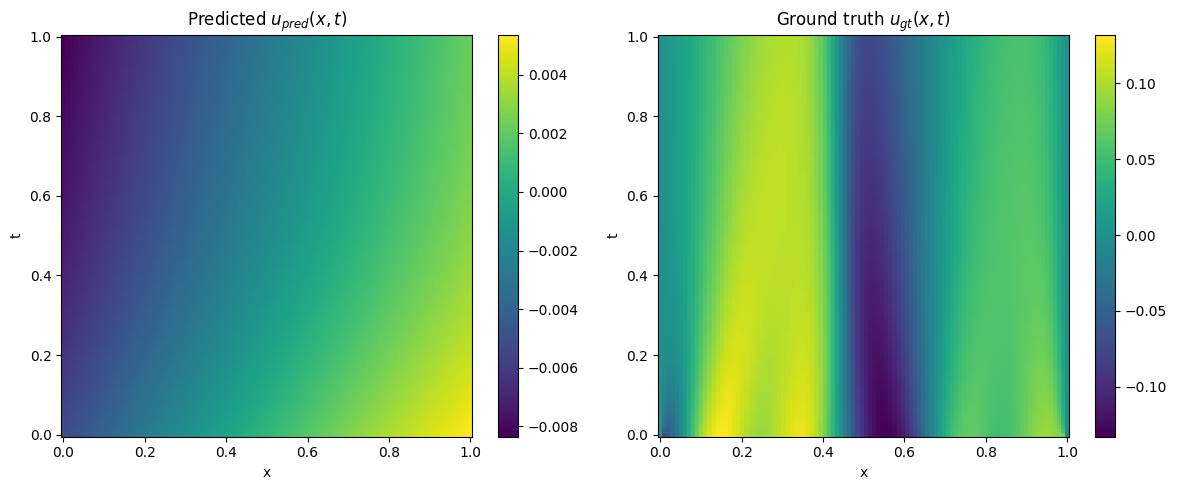

In [16]:
plot(X, T, u_pred, u_test)

Задание выполнено. Не забудьте прислать вместе с заполненным ноутбуком логи `TensorBoard`.

*Место для ваших выводов, комментариев, обратной связи (необязательно).*

## Литература
[1] Liu Z. et al. KAN: Kolmogorov-arnold networks // [arXiv preprint arXiv:2404.19756](https://arxiv.org/abs/2404.19756). – 2024.

[2] Lu L., Jin P., Karniadakis G. E.: DeepONet: Learning nonlinear operators for identifying differential equations based on the universal approximation theorem of operators // [arXiv preprint arXiv:1910.03193](https://arxiv.org/abs/1910.03193). – 2019.

[3] Abueidda D. W., Pantidis P., Mobasher M. E.: DeepOKAN: Deep Operator Network Based on Kolmogorov Arnold Networks for Mechanics Problems // [arXiv preprint arXiv:2405.19143](https://arxiv.org/abs/2405.19143). - 2024.